# Loan Prediction Dataset - Feature Engineering

## Objective

The objective of this notebook is to apply preprocessing and feature engineering steps based on decisions made during EDA.

This notebook focuses on:
- Handling missing values
- Fixing data type issues
- Creating new meaningful features
- Encoding categorical variables
- Transforming skewed numerical features
- Scaling numerical features
- Saving the processed dataset for modeling

No model training is performed in this notebook.

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [89]:
df = pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")

In [90]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Preprocessing Decisions from EDA

1. LoanAmount contains missing values → median imputation
2. Loan_Amount_Term contains missing values → median imputation
3. Gender, Married, Dependents, Self_Employed, Credit_History contain missing values → mode imputation
4. Dependents stored as object due to `3+` value → type correction required
5. ApplicantIncome, CoapplicantIncome, LoanAmount are right-skewed → log transformation required
6. Household income may be more predictive than individual income → TotalIncome feature creation
7. Loan size relative to income captures affordability → LoanIncomeRatio feature creation
8. Gender, Married, Education, Self_Employed are binary categorical → label encoding required
9. Property_Area has 3 unordered categories → one-hot encoding required
10. Dataset is slightly imbalanced → stratified splitting required during modeling

In [91]:
df.drop_duplicates(inplace = True)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


**Immputing missing values**

In [93]:
for col in ['Gender','Married','Dependents','Self_Employed','Credit_History']:
   df[col].fillna(df[col].mode()[0],inplace = True)

/tmp/ipykernel_5136/1803531830.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace = True)


In [94]:
df['LoanAmount'].fillna(df['LoanAmount'].median(),inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

/tmp/ipykernel_5136/3234925170.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(),inplace=True)
/tmp/ipykernel_5136/3234925170.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [95]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


**Dependents Fix**

In [96]:
df['Dependents'] = df['Dependents'].replace('3+',3).astype('int')

**Feature Creation**

In [97]:
df['TotalIncome'] = df['ApplicantIncome'] + df["CoapplicantIncome"]

**Why**: A bank considers household income, not applicant income alone. Combining ApplicantIncome and CoapplicantIncome captures the true repayment capacity. EDA showed both individually relate to loan approval, so combined they will be even more predictive.

<Axes: xlabel='Loan_Status', ylabel='TotalIncome'>

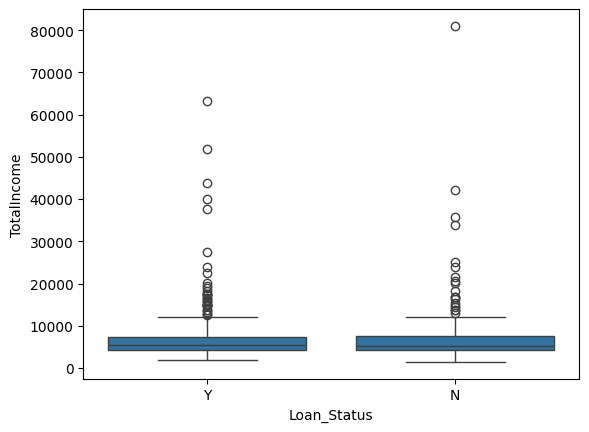

In [98]:
sns.boxplot(data = df,y = 'TotalIncome',x = 'Loan_Status')

In [99]:
df['LoanIncomeRatio'] = df['LoanAmount'] / (df['TotalIncome']+1)

Why: A loan of the same amount means something very different depending on income. This ratio captures affordability, which is how lenders actually assess risk. +1 is added to the denominator to avoid division by zero when TotalIncome is 0.

<Axes: xlabel='Loan_Status', ylabel='LoanIncomeRatio'>

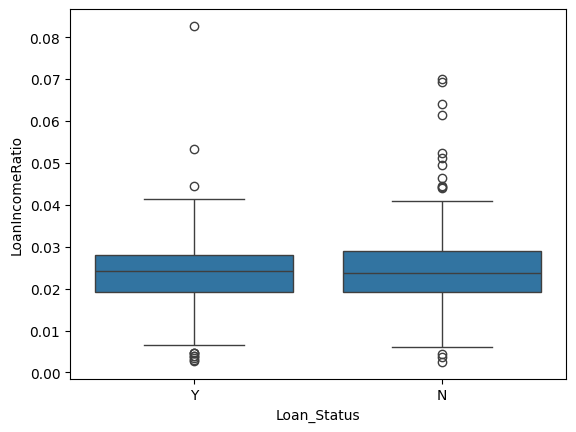

In [100]:
sns.boxplot(data = df,y = 'LoanIncomeRatio',x = 'Loan_Status')

**Log Transformation**

In [101]:
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome', 'LoanIncomeRatio']:
  df[col + '_log'] = np.log1p(df[col])

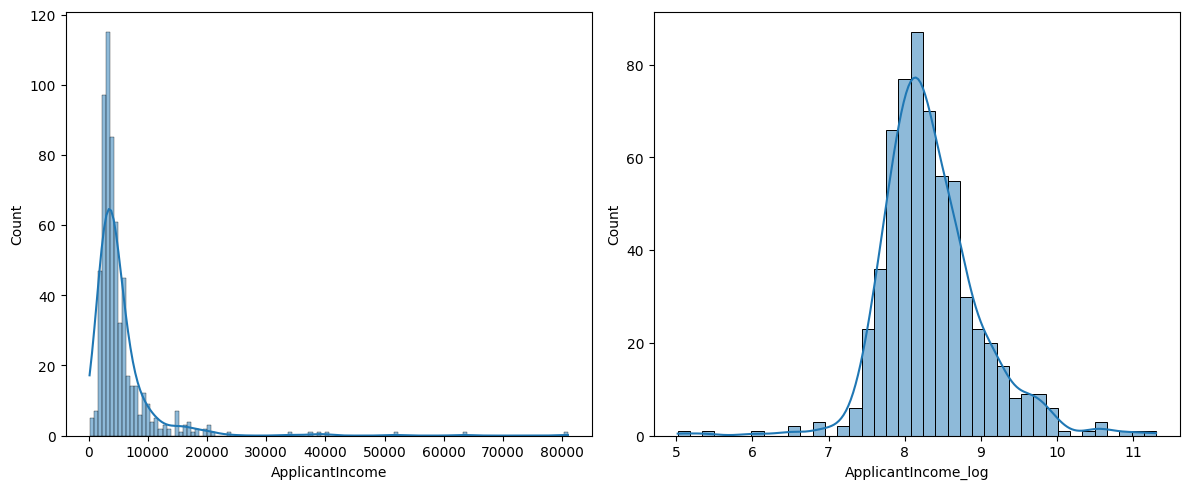

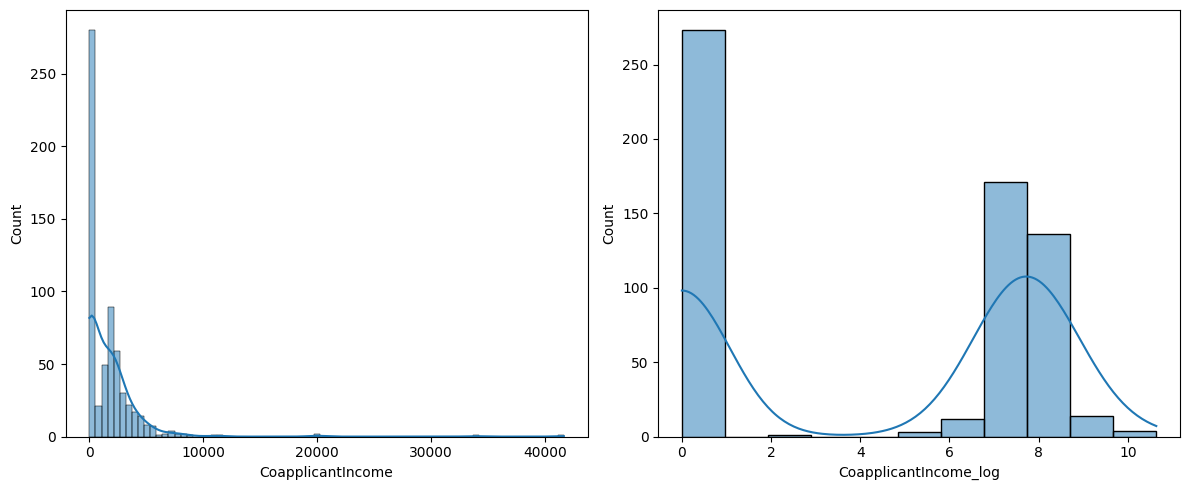

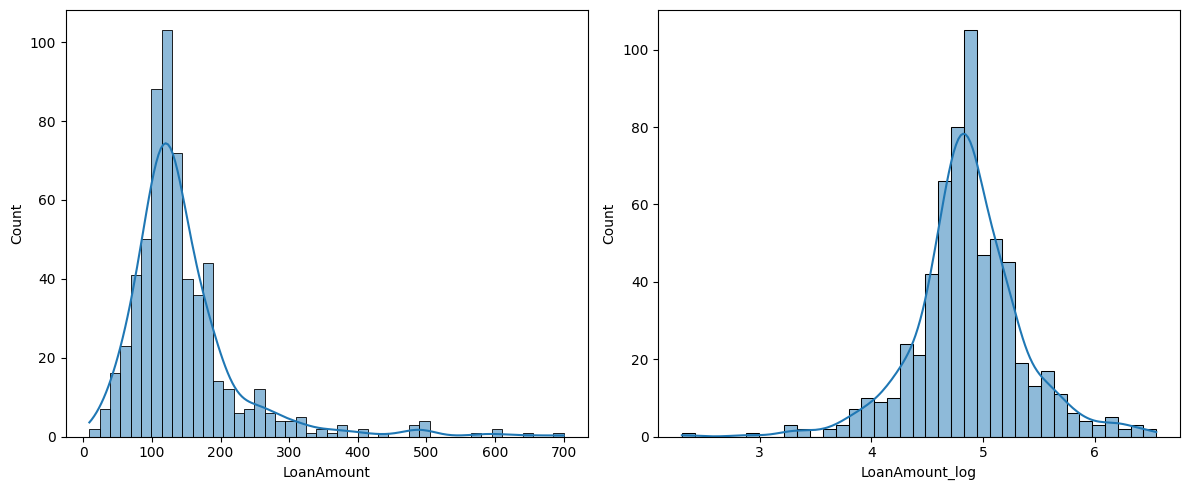

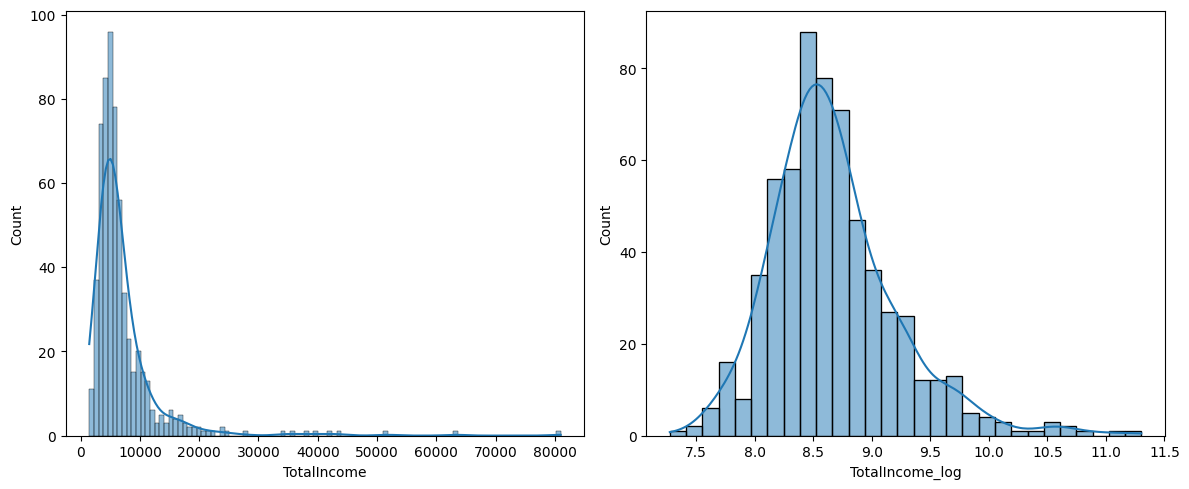

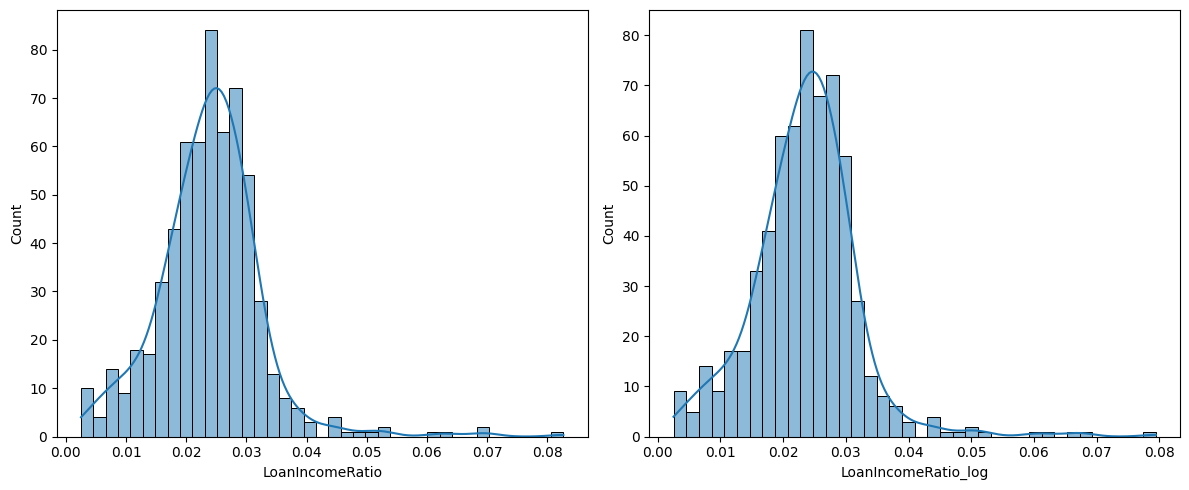

In [102]:
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome', 'LoanIncomeRatio']:
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  sns.histplot(data = df,x = col,kde = True)
  plt.subplot(1,2,2)
  sns.histplot(data = df,x = col + "_log",kde = True)
  plt.tight_layout()
  plt.show()

In [103]:
cols_to_drop = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome', 'LoanIncomeRatio', 'Loan_ID']
df.drop(columns=cols_to_drop, inplace=True)

**Encode the Target Variable**

In [104]:
df['Loan_Status'] = df['Loan_Status'].map({'Y':1,'N':0})

**Encoding Features**

In [105]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})

In [106]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,TotalIncome_log,LoanIncomeRatio_log
0,1,0,0,1,0,360.0,1.0,Urban,1,8.674197,0.000000,4.859812,8.674197,0.021644
1,1,1,1,1,0,360.0,1.0,Rural,0,8.430327,7.319202,4.859812,8.714732,0.020793
2,1,1,0,1,1,360.0,1.0,Urban,1,8.006701,0.000000,4.204693,8.006701,0.021754
3,1,1,0,0,0,360.0,1.0,Urban,1,7.857094,7.765993,4.795791,8.505525,0.023992
4,1,0,0,1,0,360.0,1.0,Urban,1,8.699681,0.000000,4.955827,8.699681,0.023224


In [107]:
df = pd.get_dummies(df,columns = ['Property_Area'],drop_first = True)

In [108]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Loan_Status,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,TotalIncome_log,LoanIncomeRatio_log,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,360.0,1.0,1,8.674197,0.000000,4.859812,8.674197,0.021644,False,True
1,1,1,1,1,0,360.0,1.0,0,8.430327,7.319202,4.859812,8.714732,0.020793,False,False
2,1,1,0,1,1,360.0,1.0,1,8.006701,0.000000,4.204693,8.006701,0.021754,False,True
3,1,1,0,0,0,360.0,1.0,1,7.857094,7.765993,4.795791,8.505525,0.023992,False,True
4,1,0,0,1,0,360.0,1.0,1,8.699681,0.000000,4.955827,8.699681,0.023224,False,True


Standard Scaling

In [109]:
num_cols = ['ApplicantIncome_log', 'CoapplicantIncome_log', 'LoanAmount_log',
            'TotalIncome_log', 'LoanIncomeRatio_log', 'Loan_Amount_Term', 'Dependents']
for col in num_cols:
  df[col + '_standardized'] = (
    (df[col] - df[col].mean()) /
    df[col].std()
  )

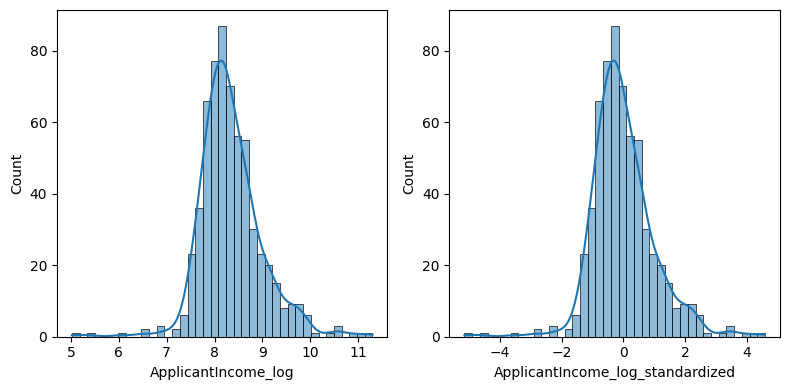

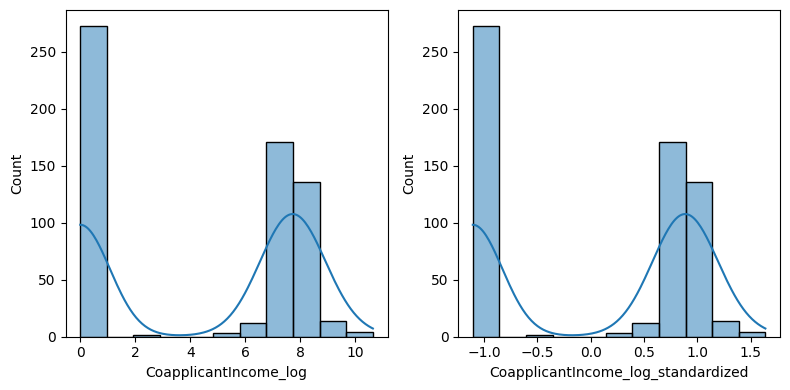

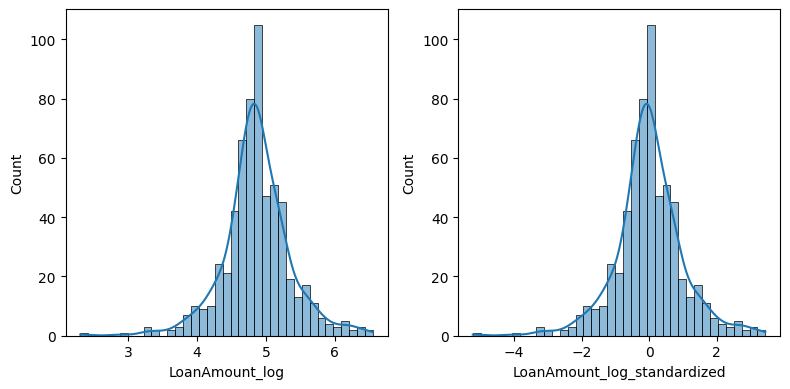

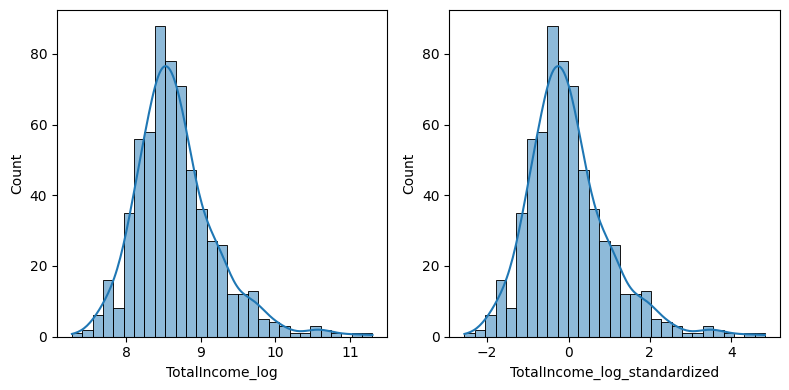

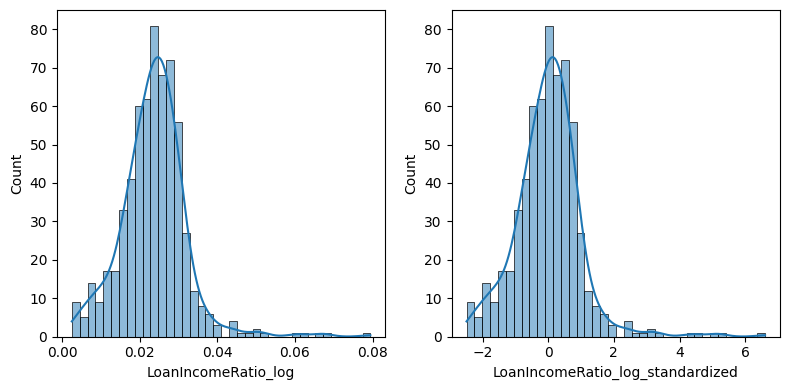

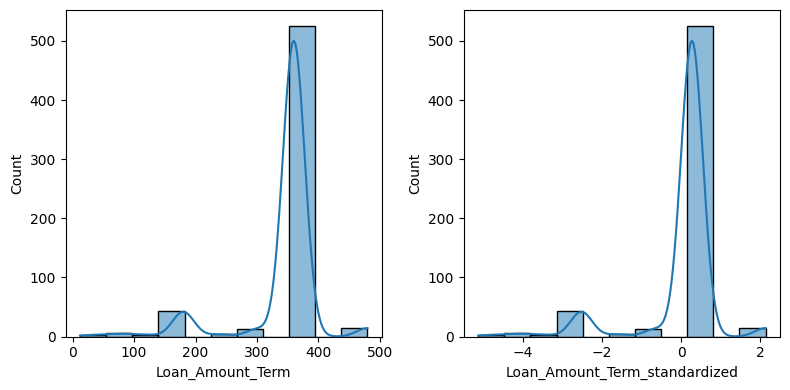

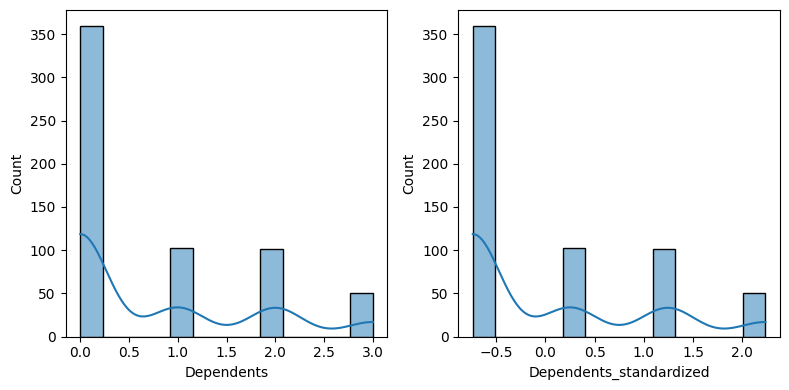

In [110]:
for col in num_cols:
  plt.figure(figsize=(8,4))
  plt.subplot(1,2,1)
  sns.histplot(data = df,x = col,kde = True)
  plt.subplot(1,2,2)
  sns.histplot(data = df,x = col + "_standardized",kde = True)
  plt.tight_layout()
  plt.show()

In [111]:
df.drop(columns=num_cols, inplace=True)

In [112]:
df.head()

,Gender,Married,Education,Self_Employed,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban,ApplicantIncome_log_standardized,CoapplicantIncome_log_standardized,LoanAmount_log_standardized,TotalIncome_log_standardized,LoanIncomeRatio_log_standardized,Loan_Amount_Term_standardized,Dependents_standardized
0,1,0,1,0,1.0,1,False,True,0.515766,-1.106881,-0.012793,0.008419,-0.225865,0.273009,-0.737205
1,1,1,1,0,1.0,0,False,False,0.137694,0.781520,-0.012793,0.082792,-0.326436,0.273009,0.253263
2,1,1,1,1,1.0,1,False,True,-0.519056,-1.106881,-1.347564,-1.216307,-0.212874,0.273009,-0.737205
3,1,1,0,0,1.0,1,False,True,-0.750992,0.896795,-0.143234,-0.301061,0.051545,0.273009,-0.737205
4,1,0,1,0,1.0,1,False,True,0.555274,-1.106881,0.182832,0.055178,-0.039137,0.273009,-0.737205


In [113]:
print(df.shape)

(614, 15)


In [114]:
df.dtypes


,0
Gender,int64
Married,int64
Education,int64
Self_Employed,int64
Credit_History,float64
Loan_Status,int64
Property_Area_Semiurban,bool
Property_Area_Urban,bool
ApplicantIncome_log_standardized,float64
CoapplicantIncome_log_standardized,float64


In [115]:
print(df.isnull().sum())

Gender                                0
Married                               0
Education                             0
Self_Employed                         0
Credit_History                        0
Loan_Status                           0
Property_Area_Semiurban               0
Property_Area_Urban                   0
ApplicantIncome_log_standardized      0
CoapplicantIncome_log_standardized    0
LoanAmount_log_standardized           0
TotalIncome_log_standardized          0
LoanIncomeRatio_log_standardized      0
Loan_Amount_Term_standardized         0
Dependents_standardized               0
dtype: int64


# Feature Engineering Summary

## Applied Transformations

1. **Duplicate Removal**
   - Removed duplicate rows from raw data

2. **Missing Value Imputation**
   - LoanAmount → Median
   - Loan_Amount_Term → Median
   - Gender, Married, Dependents, Self_Employed, Credit_History → Mode

3. **Data Type Correction**
   - Dependents → Replaced `3+` with `3`, converted to int

4. **Feature Creation**
   - TotalIncome → ApplicantIncome + CoapplicantIncome
   - LoanIncomeRatio → LoanAmount / (TotalIncome + 1)

5. **Feature Transformation**
   - Log Transformation (`log1p`) on ApplicantIncome, CoapplicantIncome, LoanAmount, TotalIncome, LoanIncomeRatio

6. **Encoding**
   - Target Encoding → Loan_Status (Y → 1, N → 0)
   - Label Encoding → Gender, Married, Education, Self_Employed
   - One-Hot Encoding → Property_Area

7. **Scaling**
   - Manual Standardization (Z-score) on all numerical columns

8. **Redundant Column Removal**
   - Dropped original pre-transformation columns and Loan_ID

The dataset is now prepared for machine learning pipelines and modeling.